# Pigeon density repartition

libraries:

In [1]:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib import gridspec
%matplotlib inline
from skimage import io
from skimage import measure
from skimage import color
from PIL import Image


from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
from shapely.validation import explain_validity, make_valid

from read_roi import read_roi_zip
from scipy.stats import kde

from utils import *

/home/jovyan
/home/jovyan/projects/cellcount


define paths and stadium-dependent options:

In [2]:
paths2folder = {
    'E12': "Cl E12 Fovea 18_2",
    'E16': "Cl E16 Fovea 40_3",
    'P12': "Cl P12 Fovea 31_2",
    '8W': "Cl 8W fovea (23) 40_1"
}
paths2image = {
    'E12': "Cl E12 Fovea 18_2 - 1 - 40x overview-Stitching-04.czi #1.tif",
    'E16': "Cl E16 Fovea 40_3 - 1 - 40x overview-Stitching-08.czi #1.tif",
    'P12': "Cl P12 Fovea 31_2 - 1 - 40x overview-Stitching-03.czi #1.tif",
    '8W': "Cl 8W fovea (23) 40_1 - 1 - 40x overview-Stitching-02.czi #1.tif"
}
paths2image_cleared = {
    'E12': "Cl E12 Fovea 18_2 - 1 - 40x overview-Stitching-04.czi #1_cleared.tif",
    'E16': "Cl E16 Fovea 40_3 - 1 - 40x overview-Stitching-08.czi #1_cleared.tif",
    'P12': "Cl P12 Fovea 31_2 - 1 - 40x overview-Stitching-03.czi #1_cleared.tif",
    '8W': "Cl 8W fovea (23) 40_1 - 1 - 40x overview-Stitching-02.czi #1_cleared.tif"
}
paths2roiset = {
    'E12': "ClE12_Fc_18_2_1_whole_RoiSet.zip",
    'E16': "ClE16_whole_40_3_1_GCL_RoiSet.zip",
    'P12': "ClP12_whole_31_2_1_GCL_RoiSet.zip",
    '8W': "Cl 8W fovea(23)_40_1_1_RoiSet.zip"
}
# ratio microns/px :
img_cleared_ratio = { 
    'E12': 2550.61/16352,
    'E16': 3415.99/21900, 
    'P12': 2905.00/18624,
    '8W': 2534.39/16248
}
print(img_cleared_ratio)
rotate = {
    'E12': False,
    'E16': True,
    'P12': False,
    '8W': False,
}
# images widths in microns (used for defining xaxis limits) :
img_width = {
    'E12': 2750,
    'E16': 2750,#3500,
    'P12': 3000,
    '8W': 2750
}

{'E12': 0.1559815313111546, 'E16': 0.15598127853881277, 'P12': 0.155981529209622, '8W': 0.1559816592811423}


In [13]:
#stade = 'E12' # define the development stadium here
#stade = 'E16'
#stade = 'P12'
stade = '8W'
path2kdrive = "/home/jovyan/kDrive"
path2mainfolder = os.path.join(path2kdrive, "tania/Epoxy_Histology/Pigeon")
path2plots = os.path.join(path2mainfolder, "plots")
path2folder = os.path.join(path2mainfolder, paths2folder[stade])
path2image = os.path.join(path2folder, paths2image[stade])
path2image_cleared = os.path.join(path2folder, paths2image_cleared[stade])
path2roiset = os.path.join(path2folder, paths2roiset[stade])

In [14]:
# im = Image.open(path2image_cleared)
# im.show()

Load image and image cleared:

In [15]:
im = io.imread(path2image)
#print(np.array(im).shape)
print(im.shape)
im_cleared = io.imread(path2image_cleared)
#im_cleared_dim = np.array(im_cleared).shape
im_cleared_dim = im_cleared.shape
print(im_cleared_dim)
if stade == 'E16': # crop image
    im_cleared_cropped = im_cleared[:, :17000]
    im_cleared_cropped_dim = im_cleared_cropped.shape
    print(im_cleared_cropped_dim)

(2700, 16248)
(2700, 16248)


Import rois and check-out the polygons from imported roiset:

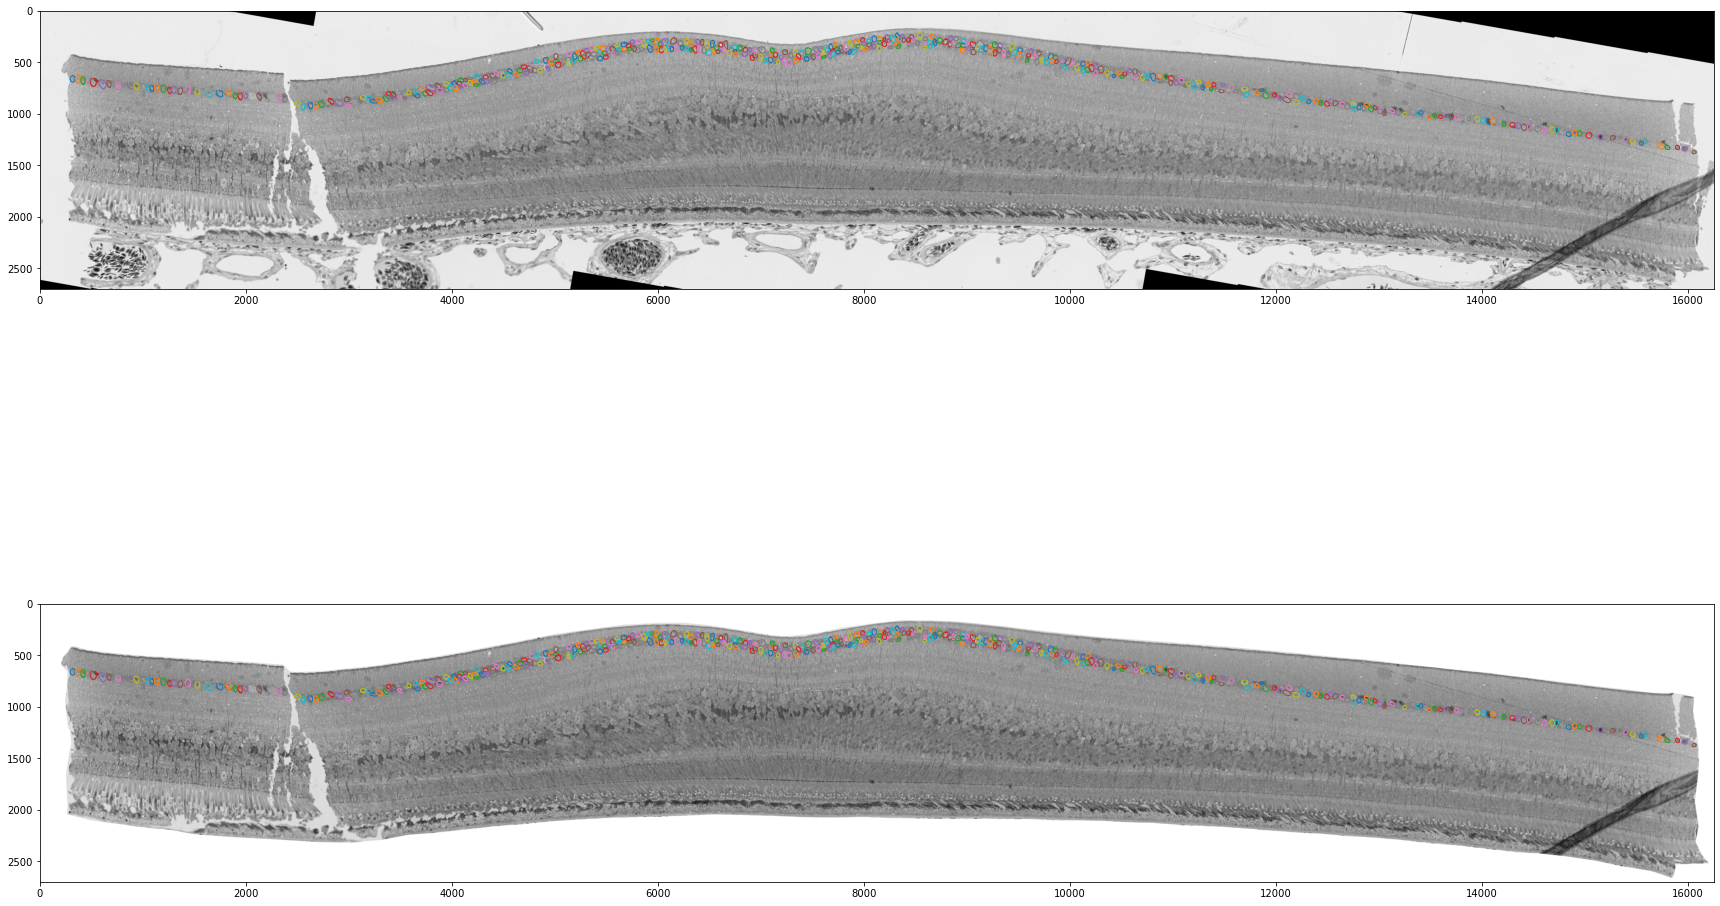

In [16]:
rois = read_roi_zip(path2roiset)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 20))
ax1.imshow(im, cmap=plt.cm.gray)
if stade == 'E16':
    ax2.imshow(im_cleared_cropped, cmap=plt.cm.gray)
else:
    ax2.imshow(im_cleared, cmap=plt.cm.gray)
# convert rois to shapely.Polygon objects, and plots the rois over the images (original and cleared, i.e., croped and rotated) :
polygon_list = []
polygon_list_cleared = []
for r in rois:
    coords = np.column_stack((rois[r]['x'], rois[r]['y']))
    polygon_list.append((r, contour2polygon(coords)))
    ax1.plot(coords[:,0], coords[:,1], linewidth=1)
    if rotate[stade]:
        # rois are rotated by 180 degrees, according to cleared image:
        coords = np.column_stack((-np.array(rois[r]['x']) + im_cleared_dim[1], -np.array(rois[r]['y']) + im_cleared_dim[0]))
    polygon_list_cleared.append((r, contour2polygon(coords)))
    ax2.plot(coords[:,0], coords[:,1], linewidth=1)    

In [17]:
# get centroids (in pixel coordinates) of each polygon, and its x-coordinate:
centroids = [polygon_list_cleared[i][1].centroid for i in range(len(polygon_list_cleared))]
centroids_x = [i.coords[0][0] for i in centroids]
nb_rois = len(centroids_x)
# remove possible duplicates:
centroids_x = list(dict.fromkeys(centroids_x))
nb_cells = len(centroids_x)
print('Number of removed duplicates :', nb_rois - nb_cells)
#centroids_x = [i.coords[0][0] * img_cleared_ratio[stade] for i in centroids]
#centroids_x_microns = [i * img_cleared_ratio[stade] for i in centroids_x]

Number of removed duplicates : 0


In [18]:
# define where the central area starts and ends, in microns ; then convert it to pixels:
central_beg = 750 / img_cleared_ratio[stade]
central_end = 1500 / img_cleared_ratio[stade]

In [19]:
def add_bracket(ax, x, y, height, width):
    ax.hlines(y=[y+height/2, y-height/2], xmin=[x-width], xmax=[x], colors=['green'], linestyles=['solid'], linewidth=2.5)
    ax.vlines(x=x, ymin=[y-height/2], ymax=[y+height/2], colors=['green'], linestyles=['solid'], linewidth=2.5)
    ax.text(x + 100, y, 'NFL', fontsize=24, color='green', va='center')
    return ax
    

In [20]:
set_annot = {
    'E12': {
        'title': 'E12', 'title_x': -2900, 'title_y': -500,
        'hblue_xmin': 750/img_cleared_ratio[stade], 'hblue_xmax': (750+397)/img_cleared_ratio[stade], 'hblue_y': 500, 'hblue_label': 397,
        'bracket_x': 2540/img_cleared_ratio[stade], 'bracket_y': 800, 'bracket_height': 480, 'bracket_width': 100,
        'arrow_target': (2520/img_cleared_ratio[stade], 1100), 'arrow_text': (2550/img_cleared_ratio[stade]+200, 1100+500)
        },
    'E16': {
        'title': 'E16', 'title_x': -2900, 'title_y': 500,
        'hblue_xmin': 1350/img_cleared_ratio[stade], 'hblue_xmax': (1350+465)/img_cleared_ratio[stade], 'hblue_y': 1500, 'hblue_label': 465,
        'bracket_x': 2675/img_cleared_ratio[stade], 'bracket_y': 1300, 'bracket_height': 550, 'bracket_width': 100,
        'arrow_target': (2660/img_cleared_ratio[stade], 1655), 'arrow_text': (2665/img_cleared_ratio[stade]+380, 1650+420)
        },
    'P12': {
        'title': 'P12', 'title_x': -2900, 'title_y': 500,
        'hblue_xmin': 1200/img_cleared_ratio[stade], 'hblue_xmax': (1200+479)/img_cleared_ratio[stade], 'hblue_y': 1000, 'hblue_label': 479,
        'bracket_x': 2850/img_cleared_ratio[stade], 'bracket_y': 700, 'bracket_height': 200, 'bracket_width': 100,
        'arrow_target': (2830/img_cleared_ratio[stade], 870), 'arrow_text': (2850/img_cleared_ratio[stade]+200, 870+650),
        'arrow_middle_target': (1500/img_cleared_ratio[stade], 1450), 'arrow_middle_text': (1500/img_cleared_ratio[stade], 1450-500),
        },
    '8W': {
        'title': 'P56', 'title_x': -2900, 'title_y': 0,
        'hblue_xmin': 950/img_cleared_ratio[stade], 'hblue_xmax': (950+400)/img_cleared_ratio[stade], 'hblue_y': 100, 'hblue_label': 400,
        'bracket_x': 2530/img_cleared_ratio[stade], 'bracket_y': 1100, 'bracket_height': 380, 'bracket_width': 100,
        'arrow_target': (2510/img_cleared_ratio[stade], 1350), 'arrow_text': (2510/img_cleared_ratio[stade]+380, 1350+480)
        }
}

<ipython-input-21-25ab0c9e7815>:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels(y_labels, fontsize=20)


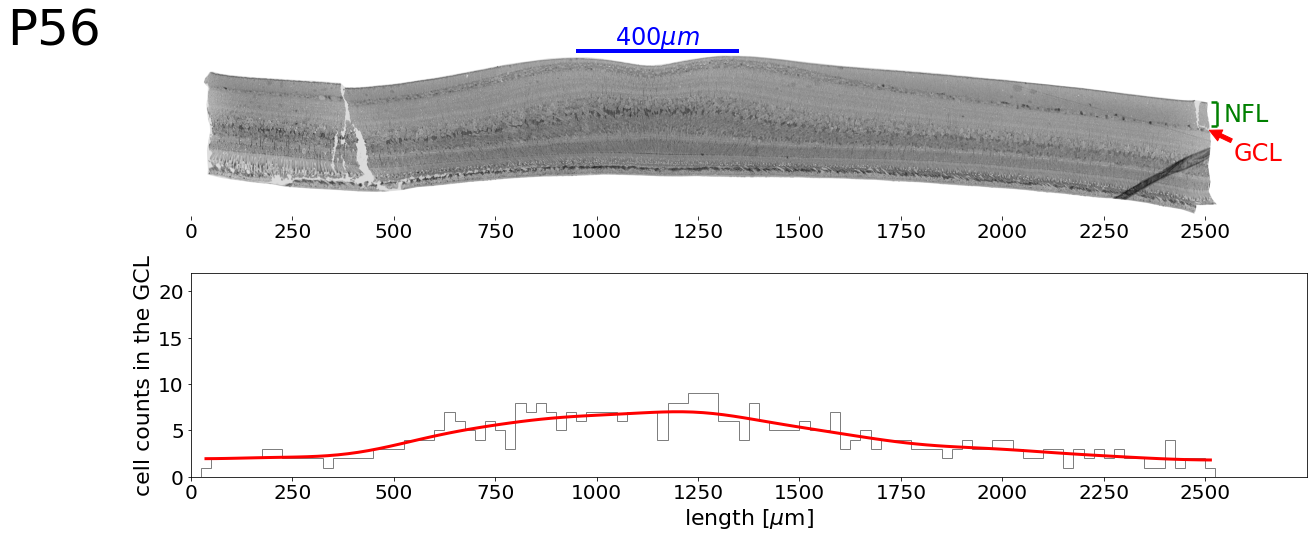

In [21]:
if stade == 'E16':
    im_cleared = im_cleared_cropped


# create a figure
fig = plt.figure(figsize=(20, 9))

# define x-axis limits, ticks and labels:
#x_axis_limits = [np.min(centroids_x) - 500, np.max(centroids_x) + 500] # defined in pixel coordinates
x_axis_limits = [0, 1/img_cleared_ratio[stade] * img_width[stade]] # defined in pixel coordinates
x_labels = np.arange(0, img_width[stade], 250) # ticks labels are in microns
x_ticks = 1/img_cleared_ratio[stade] * x_labels # ticks positions are defined in pixels, as the coordinates of rois are, as well as teh scale on image 
# print(x_ticks)
# print(x_labels)
y_ticks = np.arange(0, 25, 5)
y_labels = y_ticks
# create grid for different subplots
spec = gridspec.GridSpec(ncols=1, nrows=2, hspace=-0.0, wspace=-0, height_ratios=[1.4, 1])

ax1 = fig.add_subplot(spec[1])
#ax1.set_title(stade, fontsize=30, loc='left')
#ax1.grid(True, linestyle='-')

ax1.set_xlim(x_axis_limits[0], x_axis_limits[1])
ax1.set_xticks(x_ticks)
ax1.set_xticklabels(x_labels, fontsize=20)
ax1.set_xlabel('length [$\mu$m]', fontsize=22)
ax1.set_yticklabels(y_labels, fontsize=20)
ax1.set_ylabel('cell counts in the GCL', fontsize=22)
ax1.set_ylim(0, 22)
ax1.set_yticks(y_ticks)

# plot histogram:
bins_width = 25 # set here bins width in microns

## bins match centroids_x range : 
# bins_number = round((img_cleared_ratio[stade] * np.max(centroids_x) - img_cleared_ratio[stade] * np.min(centroids_x)) / bins_width) 
#h, bins, _ = ax1.hist(centroids_x, bins_number, density=False, color = 'white', alpha=0.5, ec='black') # histtype='stepfilled',
## bins span all image :
bins_number = round((img_cleared_ratio[stade] * x_axis_limits[1] - img_cleared_ratio[stade] * x_axis_limits[0]) / bins_width) 
h, bins, _ = ax1.hist(centroids_x, bins_number, range=(x_axis_limits[0], x_axis_limits[1]), density=False, color = 'white', alpha=0.5, ec='black', histtype='stepfilled') 
#print(bins_number)

# plot smoothed curve using 1d gaussian smoothing:
x = np.array(bins[:-1]) + (bins[1]-bins[0])/2

# trim leading and trailing zeros from histogram values:
i_low = 0
i_high = 0
for i in range(int(len(h)/2)):
    if h[i] != 0:
        i_low = i
        break
for i in range(1, int(len(h)/2)):
    if h[-i] != 0:
        i_high = i - 1
        break
if i_high > 0:
    x_trim = x[i_low : -i_high]
    h_trim = h[i_low : -i_high]
else:
    x_trim = x[i_low:]
    h_trim = h[i_low:]

y = sc.ndimage.gaussian_filter1d(h_trim, sigma=5, mode='reflect')
# y = np.convolve(a=h, v=np.array([0.25, 0.25, 0.25, 0.25]), mode='same')

ax1.plot(x_trim, y, linewidth=3, color='red')

# plot density curve:
# density = kde.gaussian_kde(centroids_x) # density kernel estimation
# x = np.linspace(x_axis_limits[0], x_axis_limits[1], 300)
# y = density(x)
# ax12 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
# ax12.set_ylabel('density', color='red')
# ax12.tick_params(axis='y', labelcolor='red')
# ax12.set_ylim(0, np.max(y) + 4e-5)
# ax12.plot(x, y, linewidth=3, color='red')

## Plot picture : 
ax2 = fig.add_subplot(spec[0])
ax2.imshow(im_cleared, cmap=plt.cm.gray)
# figure title excentered:
ax2.text(set_annot[stade]['title_x'], set_annot[stade]['title_y'], set_annot[stade]['title'], fontsize=50)
# arrows and directions:
if stade in ["E12"]:
    ax2.arrow(4900, -500, -4500, 0, head_width=250, head_length=350, linewidth=1.5, color='black', zorder=2)
    ax2.text((central_beg + central_end)/2 + 750, -150, 'central area', fontsize=24, ha='center')
    ax2.text(central_beg/2 + 280, -150, 'towards peripheral area', fontsize=24, ha='center')
    ax2.arrow(11550, -500, 4350, 0, head_width=250, head_length=350, linewidth=1.5, color='black', zorder=2)
    ax2.text((central_end + x_axis_limits[1])/2, -150, 'towards the optic disc', fontsize=24, ha='center')

ax2.text((set_annot[stade]['hblue_xmin'] + set_annot[stade]['hblue_xmax'])/2, set_annot[stade]['hblue_y'] - 100, str(set_annot[stade]['hblue_label']) + '$\mu m$', fontsize=24, color='blue', ha='center')
ax2.hlines(y=set_annot[stade]['hblue_y'], xmin=set_annot[stade]['hblue_xmin'], xmax=set_annot[stade]['hblue_xmax'], colors=['blue'], linestyles=['solid'], linewidth=4)

# add green brackets for NFL:
ax2 = add_bracket(ax2, set_annot[stade]['bracket_x'], set_annot[stade]['bracket_y'], set_annot[stade]['bracket_height'], set_annot[stade]['bracket_width'])
# add red arrow for GCL:
ax2.annotate('GCL', xy=set_annot[stade]['arrow_target'], xytext=set_annot[stade]['arrow_text'], color='red', fontsize=24, arrowprops=dict(edgecolor='red', facecolor='red', shrink=0.0))
# For P12 only, add a green arrow showing the depression min:
if stade in ['P12']:
    ax2.annotate('', xy=set_annot[stade]['arrow_middle_target'], xytext=set_annot[stade]['arrow_middle_text'], color='green', fontsize=24, arrowprops=dict(edgecolor='green', facecolor='green', shrink=0.0))

ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_labels, fontsize=20)
#ax2.set_xlabel('length [$\mu$m]', fontsize=18)
ax2.set_yticks(ticks=[])
ax2.set_xlim(x_axis_limits[0], x_axis_limits[1])
#ax2.axis('off')
ax2.set_frame_on(False)


## for checking, plot rois directly from imported roiset:
# for r in rois:
#     if rotate[stade]:
#         # rois are rotated by 180 degrees, according to cleared image:
#         coords = np.column_stack((-np.array(rois[r]['x']) + im_cleared_dim[1], -np.array(rois[r]['y']) + im_cleared_dim[0]))
#     else:
#         coords = np.column_stack((rois[r]['x'], rois[r]['y']))
#     ax2.plot(coords[:,0], coords[:,1], linewidth=1)
# ax2.xaxis.set_minor_locator(MultipleLocator(25 * 1/img_cleared_ratio[stade]))
# ax2.xaxis.grid(True, which='minor') 
# ax2.xaxis.grid(True, which='major')
plt.rcParams['savefig.dpi'] = 600
fig.savefig(os.path.join(path2plots, f"cell_density_distribution_{stade}.png"), facecolor='white')

### Comparing the density evolution between E12 and 8W:

Note: Image size for E12 and 8W are almost exactly identical. Thus, bins, img_cleared_ratio and img_width are identical

In [12]:
h_E12 = h
bins_E12 = bins
h_E12

array([ 0.,  1.,  8., 10.,  7.,  9., 11.,  9., 10., 13.,  7., 10., 11.,
       11., 10., 12., 14., 11., 12., 12., 15., 12., 12., 12., 12., 15.,
        9., 10., 16., 10., 12., 12., 10., 16., 12., 18., 18., 17., 20.,
       21., 19., 18., 14., 18., 15., 16., 14., 13., 12., 17.,  9., 13.,
       11., 15., 13., 10., 11., 11., 11.,  9., 11., 18., 12., 11.,  9.,
       10., 12.,  7.,  9.,  8.,  8., 11., 10.,  7., 10.,  7.,  5.,  5.,
        6.,  5.,  4.,  6.,  6.,  4.,  6.,  8.,  5.,  8.,  5.,  8.,  4.,
        6.,  8.,  3.,  6.,  5.,  7.,  8.,  6.,  5.,  1.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.])

In [22]:
h_8W = h
bins_8W = bins
h_8W

array([0., 1., 2., 2., 2., 2., 2., 3., 3., 2., 2., 2., 2., 1., 2., 2., 2.,
       2., 3., 3., 3., 4., 4., 4., 5., 7., 6., 5., 4., 6., 5., 3., 8., 7.,
       8., 7., 5., 7., 6., 7., 7., 7., 6., 7., 7., 7., 4., 8., 8., 9., 9.,
       9., 6., 6., 4., 8., 6., 5., 5., 5., 6., 5., 5., 7., 3., 4., 5., 3.,
       4., 4., 4., 3., 3., 3., 2., 3., 4., 3., 3., 4., 4., 3., 2., 2., 3.,
       3., 1., 3., 2., 3., 2., 3., 2., 2., 1., 1., 4., 1., 2., 2., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.])

In [23]:
periph_left_h_E12 = [h_E12[i] for i in range(len(h_E12)) if bins_E12[i + 1] < central_beg]
periph_right_h_E12 = [h_E12[i] for i in range(len(h_E12)) if bins_E12[i] > central_end]
central_h_E12 = [h_E12[i] for i in range(len(h_E12)) if bins_E12[i + 1] >= central_beg and bins_E12[i] <= central_end]
periph_left_h_8W = [h_8W[i] for i in range(len(h_8W)) if bins_8W[i + 1] < central_beg]
periph_right_h_8W = [h_8W[i] for i in range(len(h_8W)) if bins_8W[i] > central_end]
central_h_8W = [h_8W[i] for i in range(len(h_8W)) if bins_8W[i + 1] >= central_beg and bins_8W[i] <= central_end]

In [24]:
global_decrease_ratio = np.array(h_E12) / np.array(h_8W)
periph_left_decrease_ratio = np.array(periph_left_h_E12) / np.array(periph_left_h_8W)
periph_right_decrease_ratio = np.array(periph_right_h_E12) / np.array(periph_right_h_8W)
central_decrease_ratio = np.array(central_h_E12) / np.array(central_h_8W)

<ipython-input-24-844e04757654>:1: RuntimeWarning: invalid value encountered in true_divide
  global_decrease_ratio = np.array(h_E12) / np.array(h_8W)
<ipython-input-24-844e04757654>:2: RuntimeWarning: invalid value encountered in true_divide
  periph_left_decrease_ratio = np.array(periph_left_h_E12) / np.array(periph_left_h_8W)
<ipython-input-24-844e04757654>:3: RuntimeWarning: invalid value encountered in true_divide
  periph_right_decrease_ratio = np.array(periph_right_h_E12) / np.array(periph_right_h_8W)


Compute the mean and its standard error:

In [25]:
from math import isnan
mean_periph_left_decrease_ratio = np.mean([x for x in periph_left_decrease_ratio if (isnan(x) == False)])
sem_periph_left = sc.stats.sem([x for x in periph_left_decrease_ratio if (isnan(x) == False)])
print("peripheral left decrease ratio:", mean_periph_left_decrease_ratio, "peripheral left sem:", sem_periph_left)
mean_periph_right_decrease_ratio = np.mean([x for x in periph_right_decrease_ratio if (isnan(x) == False)])
sem_periph_right = sc.stats.sem([x for x in periph_right_decrease_ratio if (isnan(x) == False)])
print("peripheral right decrease ratio:", mean_periph_right_decrease_ratio, "peripheral right sem:", sem_periph_right)
mean_central_decrease_ratio = np.mean(central_decrease_ratio)
sem_central = sc.stats.sem(central_decrease_ratio)
print("central decrease ratio:", mean_central_decrease_ratio, "central sem:", sem_central)

peripheral left decrease ratio: 4.245578231292517 peripheral left sem: 0.3775526546919747
peripheral right decrease ratio: 2.7066202090592335 peripheral right sem: 0.21976010710491342
central decrease ratio: 2.273540706605223 central sem: 0.13353043631840508


In [26]:
print(mean_periph_left_decrease_ratio - 2*sem_periph_left)
print(mean_periph_right_decrease_ratio - 2*sem_periph_right)
print(mean_central_decrease_ratio + 2*sem_central)

3.4904729219085673
2.267099994849407
2.540601579242033


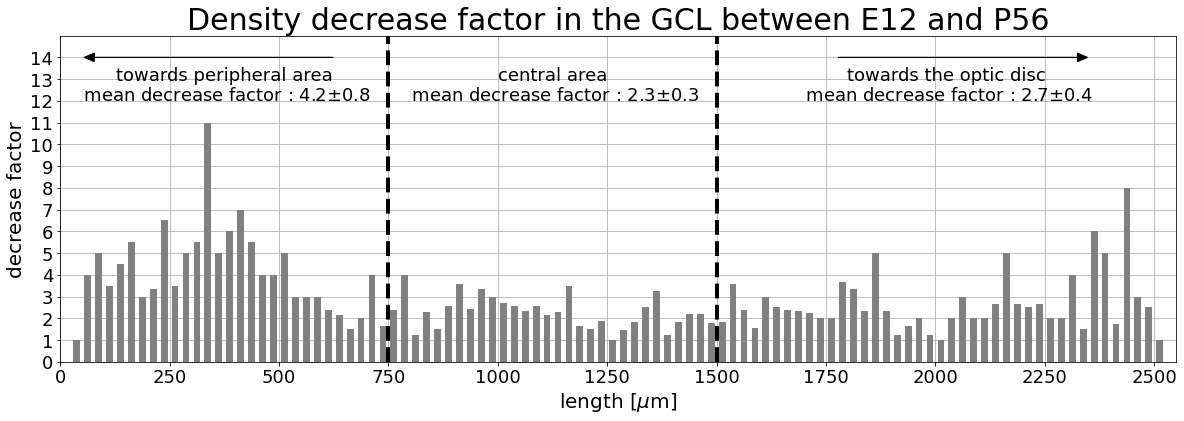

In [27]:
fig = plt.figure(figsize=(20, 6))

# define x-axis limits, ticks and labels:
x_axis_limits = [0, 1/img_cleared_ratio[stade] * (img_width[stade]-200)] # defined in pixel coordinates, same ratio and width for E12 and 8W
y_axis_limits = [0, 15]
x_labels = np.arange(0, img_width[stade], 250) # ticks labels are in microns
x_ticks = 1/img_cleared_ratio[stade] * x_labels # ticks positions are defined in pixels, as the coordinates of rois are, as well as teh scale on image 
y_ticks = np.arange(y_axis_limits[0], y_axis_limits[1], 1)
y_labels = y_ticks

ax = fig.add_subplot()
ax.set_title('Density decrease factor in the GCL between E12 and P56', fontsize=30)
ax.set_xlim(x_axis_limits[0], x_axis_limits[1])
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=18)
ax.set_xlabel('length [$\mu$m]', fontsize=20)
ax.set_ylabel('decrease factor', fontsize=20)
ax.set_ylim(y_axis_limits[0], y_axis_limits[1])
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=18)

# plot histogram:
bins_width = 25 # set here bins width in microns
bins_number = round((img_cleared_ratio[stade] * x_axis_limits[1] - img_cleared_ratio[stade] * x_axis_limits[0]) / bins_width)

ratios = [x if (isnan(x) == False) else 0 for x in global_decrease_ratio ] # replace nan values by zeroes
bars_positions = [(bins_8W[i]+bins_8W[i+1])/2 for i in range(len(bins_8W)-1)]
ax.bar(bars_positions, ratios, width=100, zorder=2, color='gray')
ax.vlines([central_beg, central_end], y_axis_limits[0], y_axis_limits[1], colors=['black'], linestyles=['dashed'], linewidth=4)
ax.arrow(4000, 14, -3500, 0, head_width=0.4, head_length=150, color='black', zorder=2)
ax.text((central_beg + central_end)/2, 12, f'central area\n mean decrease factor : {mean_central_decrease_ratio:.1f}$\pm${2*sem_central:.1f}', fontsize=18, ha='center')
ax.text(central_beg/2, 12, f'towards peripheral area\n mean decrease factor : {mean_periph_left_decrease_ratio:.1f}$\pm${2*sem_periph_left:.1f}', fontsize=18, ha='center')
ax.text((central_end + x_axis_limits[1])/2, 12, f'towards the optic disc\n mean decrease factor : {mean_periph_right_decrease_ratio:.1f}$\pm${2*sem_periph_right:.1f}', fontsize=18, ha='center')
ax.arrow(11400, 14, 3500, 0, head_width=0.4, head_length=150, color='black', zorder=2)
ax.grid()
fig.savefig(os.path.join(path2plots, "density_decrease_factor_E12_vs_P56.png"), facecolor='white')

The decrease factor shown on the y-axis is obtained as the ratio between the cell counts performed at E12 and at P56 on 25 micrometers wide frames. The mean decrease factor and its standard error is computed for the three area bounded by the vertical dashed lines.